In [3]:
import os, shutil, zipfile
from roboflow import Roboflow

In [2]:
!pip install roboflow opencv-python-headless matplotlib PyYAML
!pip install torch torchvision torchaudio


In [1]:
!git clone https://github.com/ultralytics/yolov5.git
!pip install -r yolov5/requirements.txt

Cloning into 'yolov5'...


   ---------------------------------------- 0.0/39.5 MB ? eta -:--:--
   --- ------------------------------------ 3.7/39.5 MB 16.8 MB/s eta 0:00:03
   ------- -------------------------------- 7.1/39.5 MB 17.5 MB/s eta 0:00:02
   ---------- ----------------------------- 10.5/39.5 MB 17.2 MB/s eta 0:00:02
   --------------- ------------------------ 15.2/39.5 MB 18.4 MB/s eta 0:00:02
   ------------------- -------------------- 19.7/39.5 MB 18.8 MB/s eta 0:00:02
   ------------------------ --------------- 24.1/39.5 MB 19.3 MB/s eta 0:00:01
   ---------------------------- ----------- 28.3/39.5 MB 19.3 MB/s eta 0:00:01
   --------------------------------- ------ 33.3/39.5 MB 19.8 MB/s eta 0:00:01
   -------------------------------------- - 38.3/39.5 MB 20.1 MB/s eta 0:00:01
   ---------------------------------------- 39.5/39.5 MB 19.8 MB/s eta 0:00:00
   ---------------------------------------- 0.0/41.2 MB ? eta -:--:--
   ---- ----------------------------------- 4.2/41.2 MB 20.9 MB/s eta 0:

In [ ]:


# Download and unzip Dataset1
rf = Roboflow(api_key="jAz5EeLfcszRUC74qLkS")
ds1 = rf.workspace("surf-pose-estimation").project("surf-pose-estimation-ysbb5").version(2).download("yolov5")
shutil.move(ds1.location, "Dataset1")
zip_path1 = "Dataset1/roboflow.zip"
if os.path.exists(zip_path1):
    with zipfile.ZipFile(zip_path1, 'r') as zip_ref:
        zip_ref.extractall("Dataset1")

# Download and unzip Dataset2
ds2 = rf.workspace("dronebee").project("surf-pose-estimation").version(3).download("yolov5")
shutil.move(ds2.location, "Dataset2")
zip_path2 = "Dataset2/roboflow.zip"
if os.path.exists(zip_path2):
    with zipfile.ZipFile(zip_path2, 'r') as zip_ref:
        zip_ref.extractall("Dataset2")

print("Successfully downloaded and unpacked the datasets.")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Surf-Pose-Estimation-2 in yolov5pytorch:: 100%|██████████| 40818/40818 [00:14<00:00, 2739.71it/s]


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to surf-pose-estimation-3 in yolov5pytorch:: 100%|██████████| 7166/7166 [00:02<00:00, 2995.86it/s]

Successfully downloaded and unpacked the datasets.


In [4]:
combined_path = "CombinedData"
os.makedirs(f"{combined_path}/train/images", exist_ok=True)
os.makedirs(f"{combined_path}/train/labels", exist_ok=True)

def copy_data(from_dir):
    shutil.copytree(f"{from_dir}/train/images", f"{combined_path}/train/images", dirs_exist_ok=True)
    shutil.copytree(f"{from_dir}/train/labels", f"{combined_path}/train/labels", dirs_exist_ok=True)

copy_data("Dataset1")
copy_data("Dataset2")

def clean_labels(folder):
    for fname in os.listdir(folder):
        if fname.endswith(".txt"):
            path = os.path.join(folder, fname)
            with open(path, "r") as f:
                lines = f.readlines()
            kept = [line for line in lines if line.strip().split()[0] == "0"]
            if kept:
                with open(path, "w") as f:
                    f.writelines(kept)
            else:
                os.remove(path)

clean_labels(f"{combined_path}/train/labels")
print("Datasets merged and labels cleaned.")


Datasets merged and labels cleaned.


In [1]:
import torch
torch.cuda.is_available()


True

In [6]:
import torch
print("CUDA available:", torch.cuda.is_available())
print("GPU name:", torch.cuda.get_device_name(0))
print("Current device:", torch.cuda.current_device())


CUDA available: True
GPU name: NVIDIA GeForce RTX 3080
Current device: 0


In [ ]:
combined_path = os.path.abspath("CombinedData/train/images")

yaml_text = f"""
train: {combined_path}
val: {combined_path}
nc: 1
names: ['surfer']
"""

with open("CombinedData/data.yaml", "w") as f:
    f.write(yaml_text.strip())

print("✅ Absolute paths saved to data.yaml.")


✅ Absolute paths saved to data.yaml.


In [ ]:
!python yolov5/train.py --img 640 --batch 8 --epochs 20 --data CombinedData/data.yaml --weights yolov5s.pt --name surfer-model --project CombinedData --device 0


^C


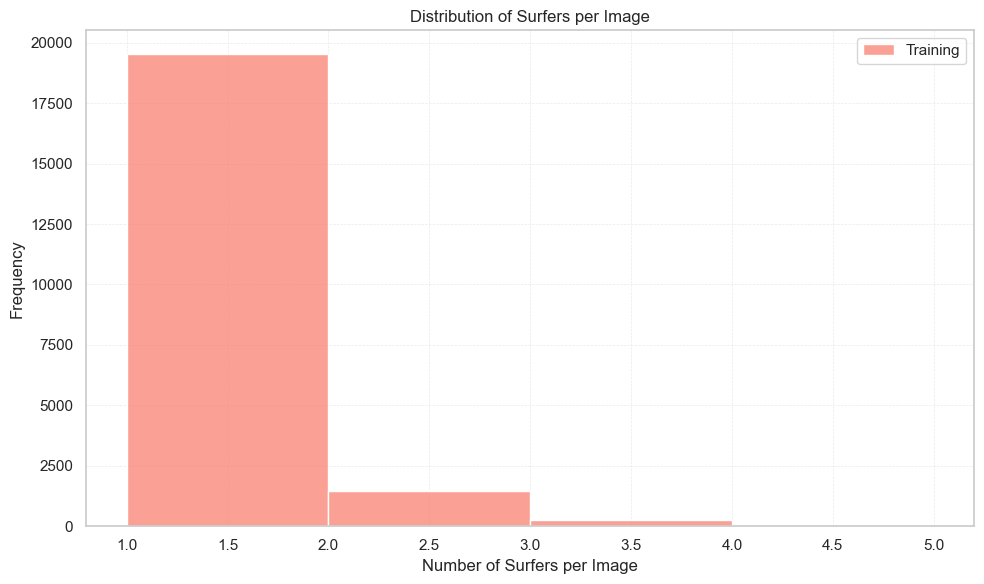

In [5]:
import os
import matplotlib.pyplot as plt
import seaborn as sns

# Folder containing YOLO-format label files
label_folder = r'C:\Users\Yining Tao\Downloads\4440-FINAL\CombinedData\train\labels'
 
# Count number of surfers (lines) per image
surfer_counts = []
for filename in os.listdir(label_folder):
    if filename.endswith(".txt"):
        with open(os.path.join(label_folder, filename), 'r') as file:
            lines = file.readlines()
            surfer_counts.append(len(lines))

# Plot with seaborn, subtle grid
sns.set(style="whitegrid")
plt.figure(figsize=(10, 6))
sns.histplot(surfer_counts, kde=False, bins=range(1, max(surfer_counts) + 2), color="salmon", label="Training")

# Adjust grid visibility
plt.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.4)

# Labels and title
plt.title("Distribution of Surfers per Image")
plt.xlabel("Number of Surfers per Image")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()
